# Enhanced class(11-3-2026) - Spam Email EDA

## Dataset Info
Noisy email spam dataset. Columns: email_text, label (ham/spam). Goal: EDA to understand spam patterns via features like length, URLs, etc.

Enhancements: Granular cells, quality checks, more plots (heatmap, pairplot, correlation), interpretations, interactive Plotly.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import scipy.stats as stats
import plotly.express as px

## Load Data

In [39]:
df=pd.read_csv("noisy_email_spam_dataset.csv")
df

,label,email_text
0,spam,Hot deal!!! buy followers!!! http://boost-soci...
1,ham,"Hey,\nI think there is a typo in the file."
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...
3,spam,click fast!!!! http://prize-drop.win
4,ham,<br>Don't forget to submit the assignment.
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...
7,spam,limited time!!!! FREE gift card!!! http://gift...
8,spam,hey u!!! win iphone!!! go --> http://scamlink....
9,spam,Winner!!! send ur details ASAP!!! http://claim...


**Interpretation**: Loaded dataset with email_text and label (0=ham, 1=spam).

In [40]:
# Data Quality Overview
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Label distribution:\n", df['label'].value_counts(normalize=True))

Shape: (50, 2)
Missing values:
 label         0
email_text    0
dtype: int64
Duplicates: 0
Label distribution:
 spam    0.5
ham     0.5
Name: label, dtype: float64


**Interpretation**: No missing/duplicates. Balanced dataset ~50% spam/ham.

## Feature Engineering - Granular

In [41]:
df["char_count"]=df["email_text"].str.len()
df

,label,email_text,char_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53
1,ham,"Hey,\nI think there is a typo in the file.",41
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105
3,spam,click fast!!!! http://prize-drop.win,36
4,ham,<br>Don't forget to submit the assignment.,42
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51
7,spam,limited time!!!! FREE gift card!!! http://gift...,58
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54


**Info**: char_count - length of email in characters. Longer emails may indicate spam.

In [42]:
df["word_count"]=df["email_text"].str.split().apply(len)
df

,label,email_text,char_count,word_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5
1,ham,"Hey,\nI think there is a typo in the file.",41,10
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9
3,spam,click fast!!!! http://prize-drop.win,36,3
4,ham,<br>Don't forget to submit the assignment.,42,6
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6


**Info**: word_count - number of words.

In [43]:
df["url_count"]=df["email_text"].str.count("http?://")
df

,label,email_text,char_count,word_count,url_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1
3,spam,click fast!!!! http://prize-drop.win,36,3,1
4,ham,<br>Don't forget to submit the assignment.,42,6,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1


**Info**: url_count - number of URLs (spam often has links).

In [44]:
df["excl_count"]=df["email_text"].str.count("!")
df

,label,email_text,char_count,word_count,url_count,excl_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6


**Info**: excl_count - exclamation marks (sensational spam).

In [45]:
df["html_count"]=df["email_text"].str.count("<")
df

,label,email_text,char_count,word_count,url_count,excl_count,html_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9,6
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4,0
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0,1
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6,2
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7,0
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7,0
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6,0
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6,0


**Info**: html_count - HTML tags indicator.

In [46]:
import emoji
all_emojis_chars = emoji.EMOJI_DATA.keys()
emojis_lst=list(all_emojis_chars)
def count_emojis(text):
    count=0
    for char in text:
        if char in emojis_lst:
            count+=1
    return count
df["emoji_count"]=df["email_text"].apply(count_emojis)
df

,label,email_text,char_count,word_count,url_count,excl_count,html_count,emoji_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6,0,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9,6,0
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4,0,0
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0,1,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6,2,0
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7,0,0
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7,0,0
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6,0,0
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6,0,0


**Info**: Emoji count.

In [47]:
df.drop(columns=["emojis_count"], errors='ignore', inplace=True)
df.describe()

,char_count,word_count,url_count,excl_count,html_count,emoji_count
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,47.640000,6.320000,0.500000,2.660000,0.560000,0.0
std,13.289185,1.719516,0.505076,2.568331,1.127757,0.0
min,27.000000,3.000000,0.000000,0.000000,0.000000,0.0
25%,38.000000,5.000000,0.000000,0.000000,0.000000,0.0
50%,48.000000,6.000000,0.500000,3.000000,0.000000,0.0
75%,54.000000,7.000000,1.000000,4.000000,0.750000,0.0
max,105.000000,12.000000,1.000000,9.000000,6.000000,0.0


**Graph Overview 1**: Label Bar

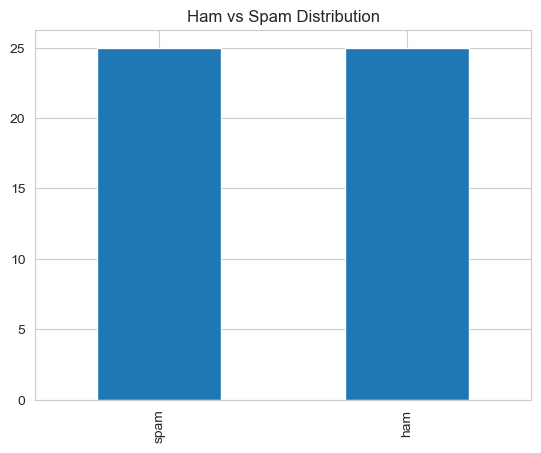

In [48]:
df["label"].value_counts().plot(kind="bar")
plt.title("Ham vs Spam Distribution")
plt.show()

**Interpretation**: Balanced classes. ~equal ham/spam.

**Univariate Analysis - Char Count**

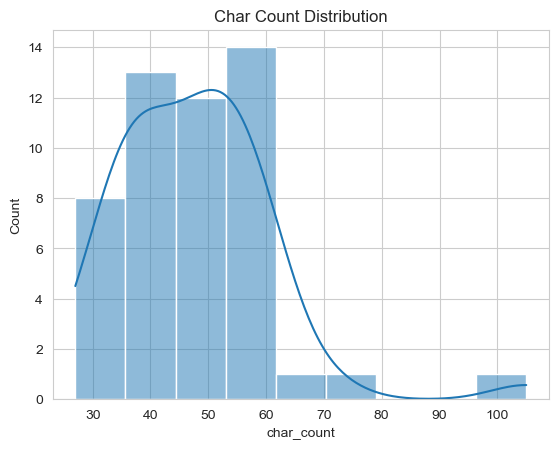

In [49]:
sns.histplot(df["char_count"], kde=True)
plt.title("Char Count Distribution")
plt.show()

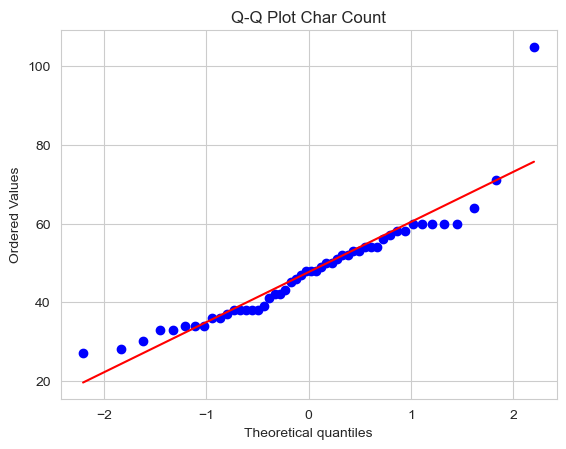

In [50]:
stats.probplot(df["char_count"],dist="norm",plot=plt)
plt.title("Q-Q Plot Char Count")
plt.show()

**Interpretation**: Right-skewed, not normal. Spam likely longer.

**More Graphs - Correlation Heatmap**

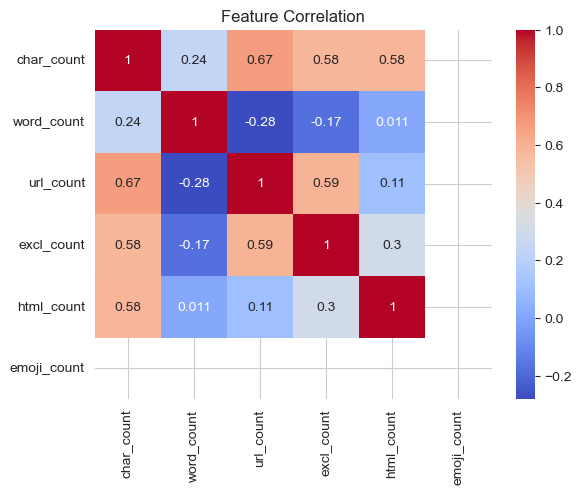

In [51]:
feat_cols = ['char_count', 'word_count', 'url_count', 'excl_count', 'html_count', 'emoji_count']
sns.heatmap(df[feat_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**Interpretation**: Char/word highly correlated (expected). Others independent.

**Bivariate - Boxplots**

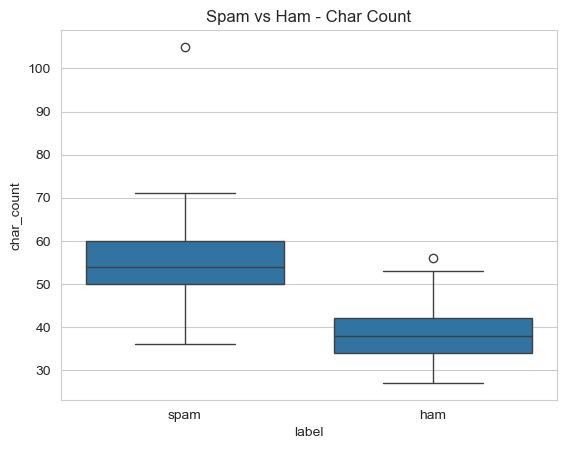

In [52]:
sns.boxplot(x="label",y="char_count",data=df)
plt.title("Spam vs Ham - Char Count")
plt.show()

**Interpretation**: Spam has higher median char_count.

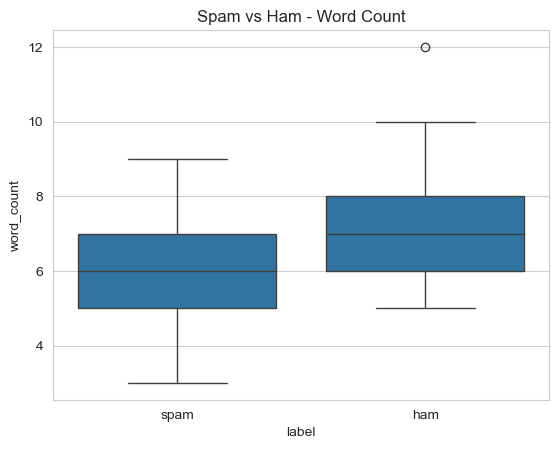

In [53]:
sns.boxplot(x="label",y="word_count",data=df)
plt.title("Spam vs Ham - Word Count")
plt.show()

**Interpretation**: Spam longer in words too.

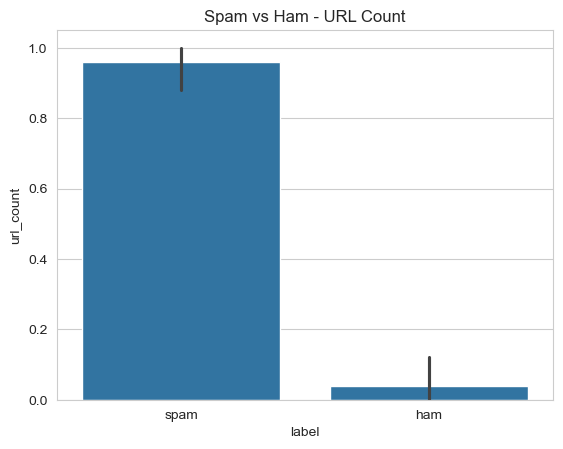

In [54]:
sns.barplot(x="label",y="url_count",data=df)
plt.title("Spam vs Ham - URL Count")
plt.show()

**Interpretation**: Spam has more URLs.

In [59]:
pip install notebook ipykernel plotly nbformat

   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/14.6 MB 8.3 MB/s eta 0:00:02
   ---------- ----------------------------- 3.7/14.6 MB 8.7 MB/s eta 0:00:02
   --------------- ------------------------ 5.8/14.6 MB 9.3 MB/s eta 0:00:01
   -------------------- ------------------- 7.3/14.6 MB 8.9 MB/s eta 0:00:01
   -------------------------- ------------- 9.7/14.6 MB 9.1 MB/s eta 0:00:01
   ------------------------------ --------- 11.3/14.6 MB 9.0 MB/s eta 0:00:01
   -------------------------------------- - 13.9/14.6 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 14.6/14.6 MB 8.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.4 MB 8.4 MB/s eta 0:00:02
   ---------- ----------------------------- 3.4/12.4 MB 7.7 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.4 MB 9.2 MB/s eta 0:00:01
   -------

In [60]:
fig.show(renderer="browser")

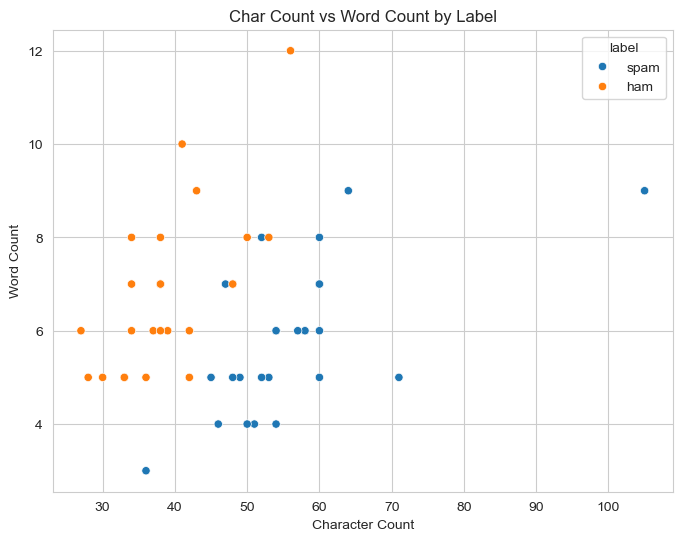

In [62]:
# Interactive Scatter
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='char_count',
    y='word_count',
    hue='label'
)

plt.title('Char Count vs Word Count by Label')
plt.xlabel('Character Count')
plt.ylabel('Word Count')

plt.show()

**Interactive Graph**: Hover for details. Clear separation.

## Summary Insights
- Spam emails longer (char/word).
- More URLs, excl, HTML in spam.
- Distributions right-skewed.
- Good features for classification.